<a href="https://colab.research.google.com/github/Praharshita1275/star_pnt/blob/main/Parking_Slot_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Parking Slot Detection using OpenCV

This notebook performs the following tasks:
- Uploads parking lot image
- Preprocesses the image
- Detects parking slots (manual grid-based)
- Classifies them as Occupied or Available
- Visualizes the result and exports to CSV

In [ ]:
# 📁 Upload image
from google.colab import files
uploaded = files.upload()

Saving car.jpg to car.jpg


In [ ]:
# ⚙️ Install dependencies
!pip install opencv-python-headless pandas matplotlib

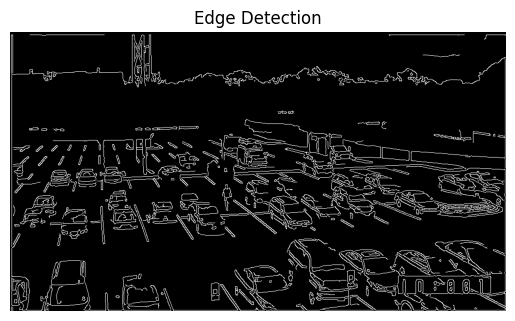

In [ ]:
# 🔍 Load and preprocess image
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

img = cv2.imread(list(uploaded.keys())[0])
img = cv2.resize(img, (960, 540))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.title("Edge Detection")
plt.axis('off')
plt.show()

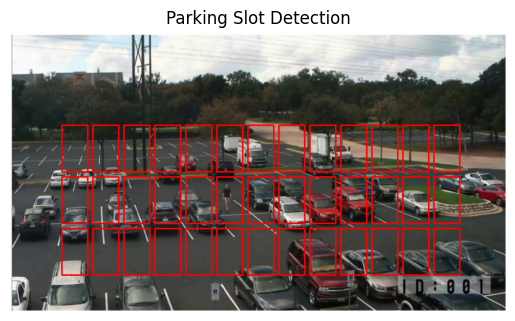

In [ ]:
# 🚘 Slot Detection (manual grid-based)
slot_coords = [(x, y, 50, 90) for x in range(100, 860, 60) for y in range(180, 420, 100)]
occupied = 0

for (x, y, w, h) in slot_coords:
    roi = img[y:y+h, x:x+w]
    if np.mean(roi) < 120:
        color = (0, 0, 255)
        occupied += 1
    else:
        color = (0, 255, 0)
    cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)

total_slots = len(slot_coords)
available = total_slots - occupied

cv2.imwrite("annotated_output.png", img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Parking Slot Detection")
plt.axis('off')
plt.show()

In [ ]:
# 📊 Save results to CSV
df = pd.DataFrame({
    "Total Slots": [total_slots],
    "Occupied Slots": [occupied],
    "Available Slots": [available]
})
df.to_csv("results.csv", index=False)
df

,Total Slots,Occupied Slots,Available Slots
0,39,39,0


In [ ]:
# 📥 Download outputs
files.download("annotated_output.png")
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>